In [14]:
import pandas as pd
import numpy as np
df=pd.read_csv("accounts.csv")
data=pd.DataFrame(df)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB
None


In [15]:
from sklearn.svm import SVR
from sklearn.model_selection import KFold,cross_val_score,GridSearchCV,train_test_split
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False)
categorical_columns=["account_type","status"]
data["open_date"]=pd.to_datetime(data["open_date"])
data["open_year"]=data["open_date"].dt.year
data["open_month"]=data["open_date"].dt.month
data["open_day"]=data["open_date"].dt.day
data=data.drop("open_date",axis=1)
encoded=encoder.fit_transform(data[categorical_columns])
print(encoded)
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(categorical_columns),
                        index=data.index)
encoded_df

[[1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [1. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


,account_type_Current,account_type_Fixed Deposit,account_type_NRI,account_type_Salary,account_type_Savings,status_Active,status_Closed,status_Dormant
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
94995,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
94996,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
94997,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
94998,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   status        95000 non-null  object 
 6   open_year     95000 non-null  int32  
 7   open_month    95000 non-null  int32  
 8   open_day      95000 non-null  int32  
dtypes: float64(1), int32(3), int64(3), object(2)
memory usage: 5.4+ MB
None


In [17]:
data=data.drop(categorical_columns,axis=1)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   account_id   95000 non-null  int64  
 1   customer_id  95000 non-null  int64  
 2   branch_id    95000 non-null  int64  
 3   balance      95000 non-null  float64
 4   open_year    95000 non-null  int32  
 5   open_month   95000 non-null  int32  
 6   open_day     95000 non-null  int32  
dtypes: float64(1), int32(3), int64(3)
memory usage: 4.0 MB
None


In [18]:
A=data.drop("balance",axis=1)
B=data["balance"]
print(A.shape)
print(B.shape)

(95000, 6)
(95000,)


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
model1=LinearRegression()
print("Multiple Linear Regression")
A_train,A_test,B_train,B_test=train_test_split(A,B,test_size=0.4,random_state=42)
A_train_scaled=scaler.fit_transform(A_train)
A_test_scaled=scaler.transform(A_test)
print("A_train_Scaled : \n",A_train_scaled[:2])
print("A_test_Scaled : \n",A_test_scaled[:2])
print(model1.fit(A_train_scaled,B_train))
B_pred1=model1.predict(A_test_scaled)
print("Multiple Linear Regression Predicted :\n",B_pred1)

Multiple Linear Regression
A_train_Scaled : 
 [[-1.15997391  0.31468959  0.24490316 -0.19671777  1.32541426 -0.98930221]
 [ 0.78725704  1.07527223 -1.39430575 -1.16584061 -0.70845387 -0.19222698]]
A_test_Scaled : 
 [[-0.14648092  0.46642418  0.77591449 -0.51975871 -1.28955905 -1.55864166]
 [-1.18922713 -1.37678649  0.66047725  0.93392554  1.03486167  1.06031982]]
LinearRegression()
Multiple Linear Regression Predicted :
 [45525.97816856 45508.37130604 45678.14592986 ... 45438.47292751
 45287.36033994 45926.19189389]


In [20]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print("Multile Linear Regression Evaluation :")
mae1=mean_absolute_error(B_test,B_pred1)
mse1=mean_squared_error(B_test,B_pred1)
rmse1=np.sqrt(mse1)
r2_1=r2_score(B_test,B_pred1)
print("Results :")
print(mae1)
print(mse1)
print(rmse1)
print(r2_1)

Multile Linear Regression Evaluation :
Results :
33369.92026791479
2075676709.227825
45559.5951389806
-0.00013559089459125317


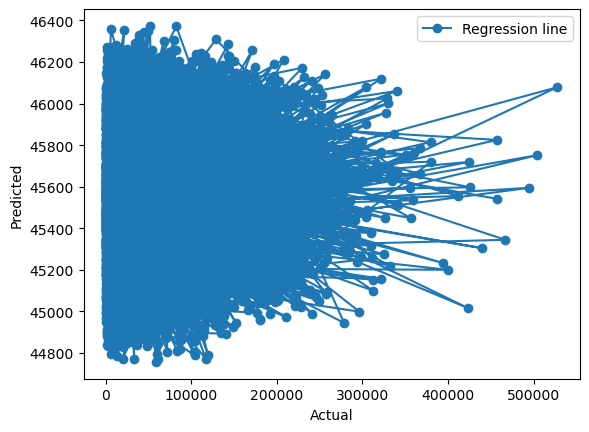

In [21]:
import matplotlib.pyplot as plt
plt.plot(B_test,B_pred1,marker="o",label="Regression line")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures
print("Polynomial Regression : ")
model2=LinearRegression()
poly=PolynomialFeatures(degree=2)
A_train_poly=poly.fit_transform(A_train_scaled)
A_test_poly=poly.transform(A_test_scaled)
model2.fit(A_train_poly,B_train)
B_pred2=model2.predict(A_test_poly)
print(B_pred2)

Polynomial Regression : 
[44824. 45836. 45040. ... 44684. 46108. 47284.]


In [23]:
print("Evaluation :")
mae2=mean_absolute_error(B_test,B_pred2)
mse2=mean_squared_error(B_test,B_pred2)
rmse2=np.sqrt(mse2)
r2_2=r2_score(B_test,B_pred2)
print(mae2,"\n",mse2,"\n",rmse2,"\n",r2_2)
      

Evaluation :
33375.26753552631 
 2076105565.2584395 
 45564.301434987894 
 -0.00034222913342696337


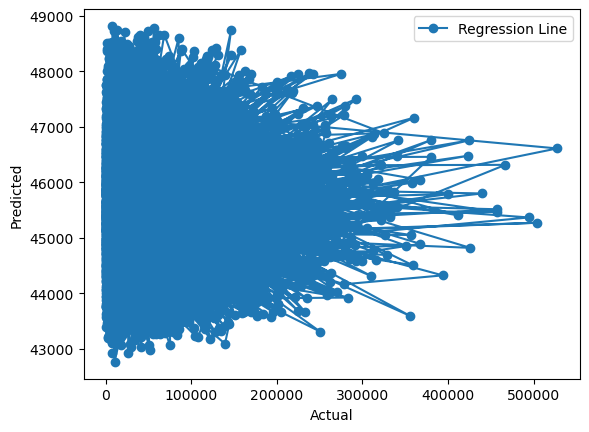

In [24]:
plt.plot(B_test,B_pred2,marker="o",label="Regression Line")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [46]:
from sklearn.svm import SVR
from sklearn.model_selection import KFold,cross_val_score,GridSearchCV
print("Support Vector Regression :")
svr=SVR(kernel='rbf',
        C=100,
        epsilon=0.2,
        gamma="scale")
svr.fit(A_train_scaled[:5000],B_train.iloc[:5000])
B_pred3=svr.predict(A_test_scaled[:5000])
print(B_pred3)

Support Vector Regression :
[31889.47633545 32695.36705457 32699.64783937 ... 32334.7410119
 32715.9024354  32943.67584159]


In [25]:
print("Training samples:", A_train_scaled.shape[0])
print("Features:", A_train_scaled.shape[1])

Training samples: 57000
Features: 6


In [52]:
print("Evaluation : ")
mae3=mean_absolute_error(B_test[:5000],B_pred3)
mse3=mean_squared_error(B_test[:5000],B_pred3)
rmse3=np.sqrt(mse3)
r2_3=r2_score(B_test[:5000],B_pred3)
print(mae3,"\n",mse3,"\n",rmse3,"\n",r2_3)

Evaluation : 
31524.324241209877 
 2316765009.112253 
 48132.78517925441 
 -0.08079442725571617


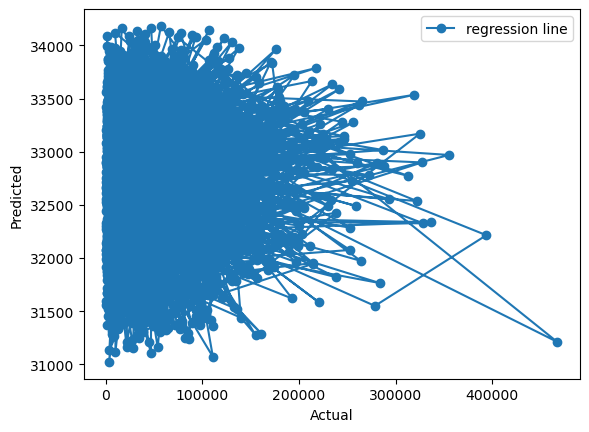

In [56]:
plt.plot(B_test[:5000],B_pred3,marker="o",label="regression line")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

In [67]:
print("Cross Validation :")
A_train_small=A_train_scaled[:50]
B_train_small=B_train[:50]
svr_cv=SVR(
    epsilon=0.2,
    C=100,
    gamma="scale",
    kernel="rbf")

    
kf=KFold(n_splits=5,shuffle=True,random_state=42)
Score=cross_val_score(svr_cv,A_train_small,B_train_small,cv=kf,scoring="r2")
print(Score)

Cross Validation :
[-0.22757675  0.00165279 -0.12391719 -0.04300447 -0.08199331]


In [71]:
print("Fine Tuned SVR")
param_grid={
    "kernel":["rbf"],
    "C":[100,1000],
    "epsilon":[0.3,0.4],
    "gamma":["scale",0.1,0.01],
}
A_test_small=A_test_scaled[:50]
grid_search=GridSearchCV(estimator=SVR(),param_grid=param_grid,cv=5,scoring="r2")
grid_search.fit(A_train_small,B_train_small)
best_svr=grid_search.best_estimator_
B_tuned=best_svr.predict(A_test_small)
print(B_tuned)

Fine Tuned SVR
[44999.21127213 43874.44837483 44113.08507213 45709.30930252
 45775.18372683 46044.75302365 47937.74335288 43753.85947632
 43046.92098141 45502.01265523 46424.74492535 42708.45701959
 44962.71395937 43104.63794239 47356.61843417 45911.89504682
 43247.34069938 44464.18202179 44003.81646278 43341.26297113
 45208.70781386 45346.33850634 44351.46643032 45095.57157932
 44018.5754995  45283.67951129 46775.0887381  47832.27897449
 47474.75633559 44587.96257327 48322.36920363 42295.31445371
 43738.80586846 45319.4730176  44910.04484828 44698.46628525
 46651.12304703 45387.87587177 47010.27869195 43735.10867495
 46026.49294531 47108.26115169 42414.87734868 42845.43182912
 47759.69566648 47103.35357934 46809.04156973 42734.11171659
 46124.3899393  47798.42524152]


In [69]:
print("Fine Tuned SVR")

param_grid = {
    "C": [1, 10, 100],
    "epsilon": [0.1, 0.2],
    "gamma": ["scale", 0.01],
    "kernel": ["rbf"]
}

A_train_small = A_train_scaled[:50]
B_train_small = B_train.iloc[:50]

A_test_small = A_test_scaled[:50]

grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Grid Search Started...")

grid_search.fit(A_train_small, B_train_small)

print("Grid Search Completed!")

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV R²:")
print(grid_search.best_score_)

best_svr = grid_search.best_estimator_

B_tuned = best_svr.predict(A_test_small)

print("Tuned Predictions:")
print(B_tuned)

Fine Tuned SVR
Grid Search Started...
Grid Search Completed!
Best Parameters:
{'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV R²:
-0.7766854823433385
Tuned Predictions:
[44819.54446229 44699.70460125 44745.24571091 44881.0367812
 44883.0157373  44908.67632321 45107.11745166 44665.1840455
 44691.55991122 44867.75149533 44951.76961414 44621.71570423
 44850.5775461  44643.0555238  45018.33846369 44919.67477869
 44626.96953567 44740.89830099 44717.23085429 44672.73872438
 44868.8410106  44832.94820162 44795.50799473 44809.74557431
 44720.1770071  44845.17762099 44963.18239387 45083.99939973
 45116.99780564 44739.98505502 45136.92396421 44579.67585977
 44681.58207608 44871.55852604 44805.54083836 44805.76603339
 44986.48869239 44844.66131262 44990.9041807  44700.71798346
 44930.83740561 45018.96169751 44633.2119401  44615.33451075
 45077.41168178 44994.01501388 44982.87722669 44623.56624483
 44917.313712   45087.43106294]


In [73]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree
tree=DecisionTreeRegressor(max_depth=2)
tree.fit(A_train_scaled,B_train)
B_tree=tree.predict(A_test_scaled)
print(B_tree)

[45566.44197044 45566.44197044 45566.44197044 ... 45566.44197044
 45566.44197044 45566.44197044]


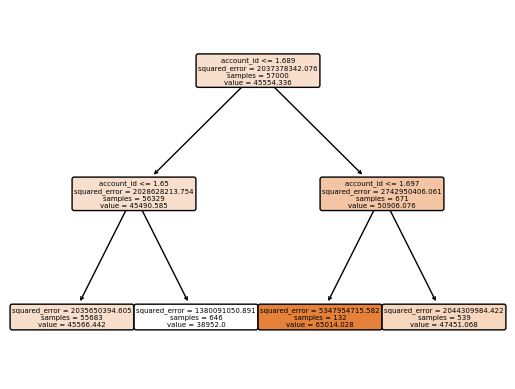

In [77]:
plot_tree(tree,filled=True,rounded=True,feature_names=A.columns)
plt.show()

In [85]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest Regression")

forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training started...")

forest.fit(A_train_scaled, B_train)

print("Training completed!")

B_forest = forest.predict(A_test_scaled)

print("Predictions:")
print(B_forest[:10])

Random Forest Regression
Training started...
Training completed!
Predictions:
[55311.9213 63086.0329 50872.7413 41727.1838 44082.8402 49760.9273
 49380.4913 52497.7243 62746.4435 46968.765 ]
